# 01 — Exploratory Data Analysis

Explores the class layout, recording durations, and raw waveform / spectrogram characteristics of the HydroSense corpus (README §6).

> The real ShipsEar dataset is access-gated (University of Vigo — README §6) and is not bundled with this repository. This notebook runs against the **synthetic hydrophone-audio generator** (`src.data.synthetic`, see `data/README.md`), which reproduces ShipsEar's 5-category class layout and imbalance at small scale so every cell below runs end-to-end without the real corpus. Point `RAW_DIR` at `data/raw/shipsear` instead to run this against the real dataset once you have access.

In [1]:
import os
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate repo root (pyproject.toml not found)")


REPO_ROOT = _find_repo_root(Path.cwd())
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Working directory: {REPO_ROOT}")


Working directory: Z:\hydrosense


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data.synthetic import CLASS_PROFILES, generate_synthetic_dataset
from src.preprocessing.representations import mel_spectrogram

SAMPLE_RATE = 16000
RAW_DIR = REPO_ROOT / "data" / "raw" / "notebook_demo_eda"


## Generate the demo corpus

Mirrors the real ShipsEar class imbalance (README §6) at small scale.

In [3]:
records = generate_synthetic_dataset(
    output_dir=RAW_DIR,
    recordings_per_class={"A": 6, "B": 8, "C": 10, "D": 5, "E": 4},
    duration_range_s=(20.0, 60.0),
    sample_rate=SAMPLE_RATE,
    seed=42,
)
metadata = pd.DataFrame(records)
metadata.head()


,recording_id,file_path,class_name,duration_s
0,A_000,Z:\hydrosense\data\raw\notebook_demo_eda\A_000...,A,50.958242
1,A_001,Z:\hydrosense\data\raw\notebook_demo_eda\A_001...,A,37.555138
2,A_002,Z:\hydrosense\data\raw\notebook_demo_eda\A_002...,A,54.343917
3,A_003,Z:\hydrosense\data\raw\notebook_demo_eda\A_003...,A,47.894721
4,A_004,Z:\hydrosense\data\raw\notebook_demo_eda\A_004...,A,23.767094


## Class distribution and duration

In [4]:
class_counts = metadata["class_name"].value_counts().sort_index()
print(class_counts)
print(f"\ntotal recordings: {len(metadata)}")
print(f"total duration:   {metadata['duration_s'].sum() / 60:.1f} min")


class_name
A     6
B     8
C    10
D     5
E     4
Name: count, dtype: int64

total recordings: 33
total duration:   23.5 min


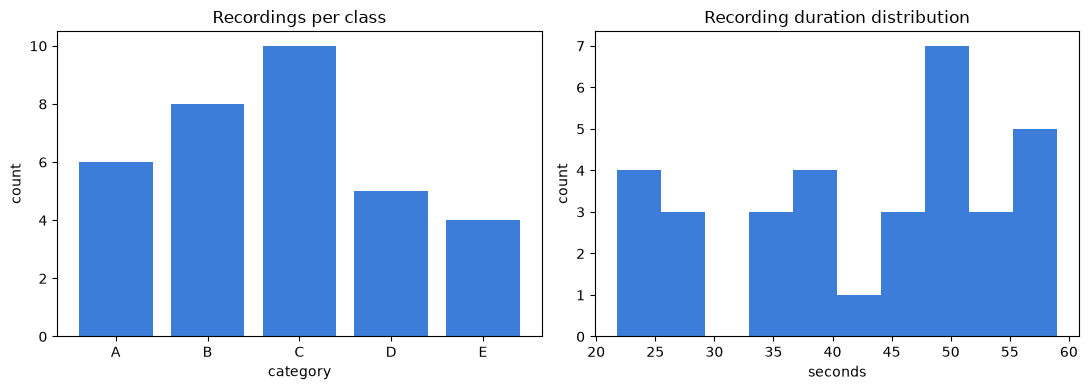

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(class_counts.index, class_counts.values, color="#3b7dd8")
axes[0].set_title("Recordings per class")
axes[0].set_xlabel("category")
axes[0].set_ylabel("count")

axes[1].hist(metadata["duration_s"], bins=10, color="#3b7dd8")
axes[1].set_title("Recording duration distribution")
axes[1].set_xlabel("seconds")
axes[1].set_ylabel("count")

fig.tight_layout()
plt.show()


## Per-class waveform and mel-spectrogram examples

Categories differ in fundamental frequency and harmonic density (`CLASS_PROFILES` in `src/data/synthetic.py`) — a synthetic stand-in for how real vessel classes differ in shaft rate / blade count.

Z:\hydrosense\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


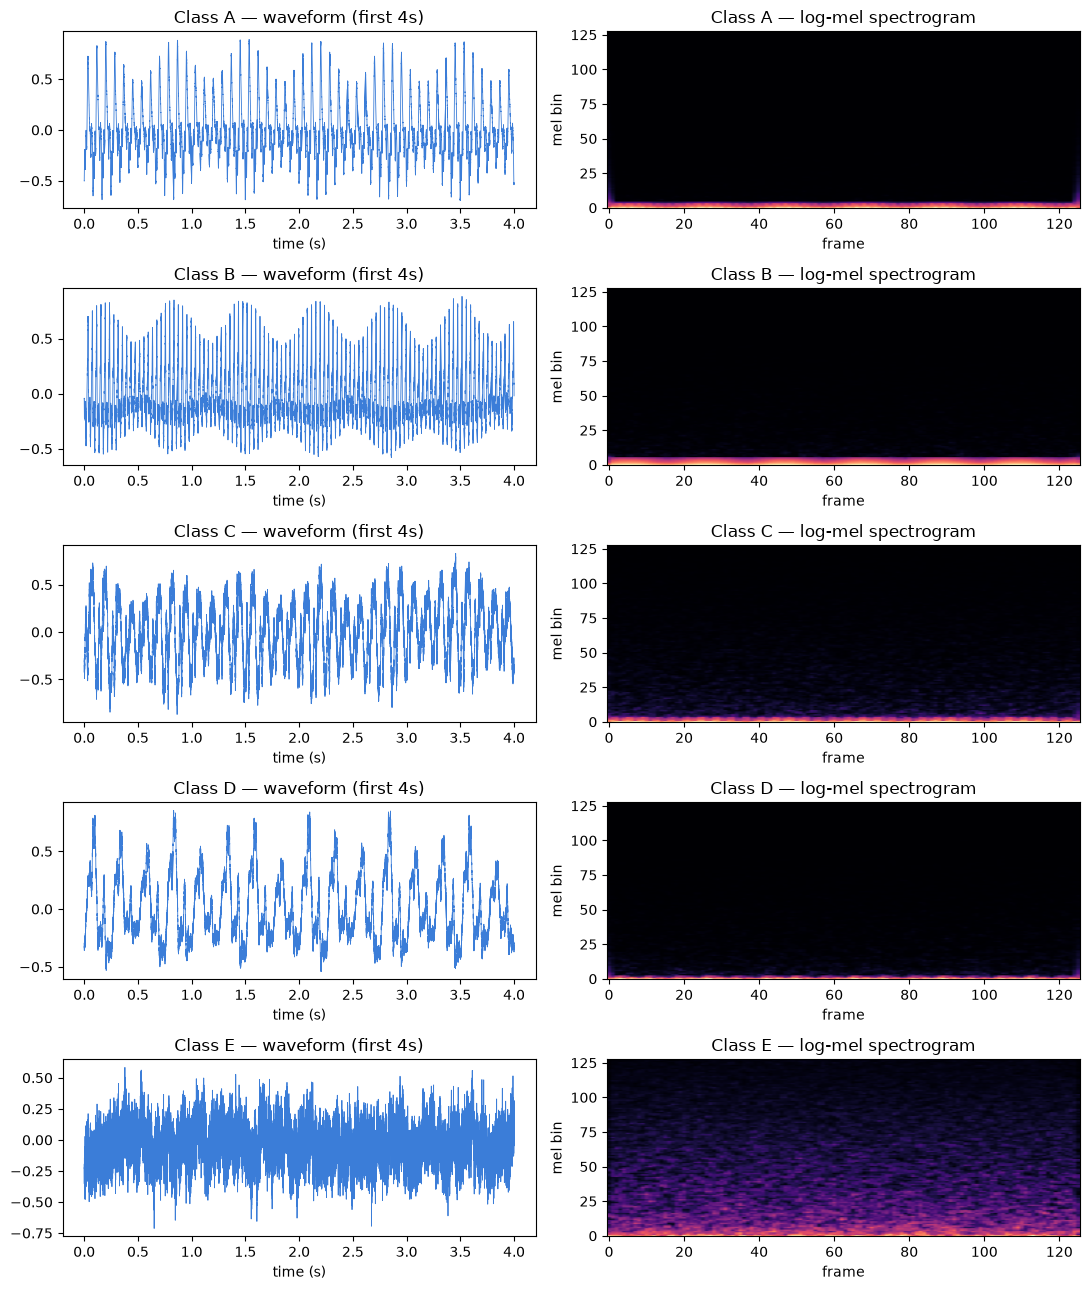

In [6]:
import soundfile as sf

class_names = sorted(CLASS_PROFILES)
fig, axes = plt.subplots(len(class_names), 2, figsize=(11, 2.6 * len(class_names)))

for row, class_name in enumerate(class_names):
    example_path = metadata[metadata["class_name"] == class_name].iloc[0]["file_path"]
    waveform, sr = sf.read(example_path, dtype="float32")
    clip = waveform[: int(4 * sr)]  # first 4s for readability

    t = np.arange(len(clip)) / sr
    axes[row, 0].plot(t, clip, linewidth=0.6, color="#3b7dd8")
    axes[row, 0].set_title(f"Class {class_name} — waveform (first 4s)")
    axes[row, 0].set_xlabel("time (s)")

    mel = mel_spectrogram(clip, sr)
    axes[row, 1].imshow(np.log1p(mel), aspect="auto", origin="lower", cmap="magma")
    axes[row, 1].set_title(f"Class {class_name} — log-mel spectrogram")
    axes[row, 1].set_xlabel("frame")
    axes[row, 1].set_ylabel("mel bin")

fig.tight_layout()
plt.show()


## Observations

- Classes **A**/**D** carry a low fundamental with a dense harmonic series (slow, large shafts), visible as horizontal striping low in the spectrogram.
- Class **E** (ambient, no vessel) is broadband noise only — no harmonic structure.
- The class imbalance mirrored from ShipsEar (D and E under-represented) is the motivation for the TimeGAN augmentation pipeline explored in `03_timegan_validation.ipynb`.